# Where Does the Optimizer Fit?

Imagine you are standing on a mountain in dense fog. Your goal is to get to the absolute bottom of the valley (Zero Error).

Here is the life cycle of a single training step in a neural network:

- **The Forward Pass:** The model takes a guess. (e.g., "The next letter is Z").
- **The Loss:** We calculate how terribly wrong that guess was. This is your *Altitude*. High altitude = bad guess.
- **Backpropagation (The Gradients):** Using calculus, the GPU calculates the slope of the ground under your feet for every single parameter. It says: "If you move this specific weight matrix a tiny bit to the left, you will go downhill."
- **The Optimizer (The Legs):** Backpropagation only tells you the direction. The Optimizer actually *takes the step*. It decides exactly how big of a step to take, how fast to move, and whether to build up momentum.

## What is AdamW? (The 1D GPS)

For years, the simplest optimizer was **SGD** (Stochastic Gradient Descent). It just took the gradient and took a dumb, fixed-size step. If the valley was flat, it crawled. If it was steep, it bounced out of control.

**Adam** (Adaptive Moment Estimation) fixed this by acting like a highly intelligent GPS. Instead of a global step size, Adam gives every single parameter its own personal speed limit by tracking two things:

- **Momentum (1st Moment):** Are we consistently moving in the same direction? If yes, build up speed and roll down the hill faster.
- **Variance (2nd Moment):** Is the gradient bouncing wildly back and forth? If yes, hit the brakes and take tiny, careful steps so we don't explode.

### The Flaw of Adam: It is blind to geometry.

If you have a massive $1000 \times 1000$ linear matrix in your SwiGLU block, Adam treats it as $1{,}000{,}000$ flat, independent numbers. It calculates $1{,}000{,}000$ independent momentum speeds. It ignores the fact that these numbers form a 2D geometric grid.

Imagine your rubber sheet is a simple $2 \times 2$ grid (4 corners).When the model is wrong, the gradient tells Adam: "Corner A was way off, pull it hard! Corner B was only slightly off, pull it a little."What Adam does:Adam is basically four blindfolded people standing at the four corners of the rubber sheet.They do not talk to each other.The person at Corner A yanks the rubber backward with a ton of force.The person at Corner B gently nudges their corner.The Result: The rubber sheet violently warps. It gets stretched incredibly thin in one direction and bunched up in another. If you do this thousands of times (training steps), the geometry of the layer becomes severely distorted. Some pathways become massive (overused), and some become crushed to zero (dead neurons). Adam is messy.

## Muon (MomentUm Orthogonalized by Newton-Schulz)

Labs like Moonshot AI used it to train their massive 1-Trillion parameter model (Kimi K2) that rivals GPT-4.

Muon trains models **faster**, utilizes the parameter space **better**, and is currently taking the open-source AI community by storm.

The Muon Way: The 2D "Geometric Spinner"Muon looks at the exact same $2 \times 2$ rubber sheet.But Muon is not four blindfolded people. Muon is a single machine that grabs the entire sheet at once.When the gradient says "Corner A is way off," Muon refuses to just blindly yank Corner A. Instead, it runs a math formula (Newton-Schulz) that calculates how to rotate the entire sheet uniformly.What Muon does:Instead of stretching and distorting the rubber, Muon pivots the whole shape. It equalizes the forces. In math, this is called Orthogonalization. An orthogonal matrix is perfectly balanced—it preserves the exact length and area of whatever you put inside it; it just changes the direction.The Result: The rubber sheet never gets warped, stretched out, or bunched up. It stays perfectly square, but it points in a new, smarter direction. Because the matrix geometry stays perfectly healthy, you can take massive, fast steps down the loss curve without the model exploding.

## A Concrete Example with Numbers

Let's say your model needs to update a simple matrix based on a bad guess. Here is the Gradient (the suggested correction):

$$G = \begin{bmatrix} 10 & 0 \\ 0 & 1 \end{bmatrix}$$

**Adam** looks at those numbers individually. It sees a $10$ and thinks, "I need to blast the top-left corner with a huge update." It applies a massive change to the top-left, and barely touches the bottom-right. The matrix loses its structural balance.

**Muon** looks at the whole shape. It says, "If I apply a 10 here and a 1 there, the matrix will warp." It runs its 5-step loop to orthogonalize $G$. It mathematically crushes that imbalanced matrix into something perfectly balanced, like:

$$G_{\text{orthogonal}} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

It then uses this beautifully balanced matrix to update the weights. Every dimension gets fair treatment.

### Why does this matter for Large Language Models?

Inside a modern LLM, these matrices aren't $2 \times 2$. They are $4096 \times 4096$.

When Adam trains a 4096-dimension matrix, millions of those independent numbers get stretched into oblivion or crushed to zero, meaning the AI is physically wasting huge chunks of its "brain" because the geometry got ruined.

Muon forces the matrix to stay geometrically perfect. The AI is forced to use its **entire brain** equally.

> "If a certain part of the matrix (a specific logic pathway) isn't useful for the current task, why on earth would we force the optimizer to update it equally? Shouldn't we just leave the useless parts alone?"

The answer is **Yes** for short-term memorization, but **No** for deep, long-term intelligence.

## The "Rich Get Richer" Problem (Why Adam Fails at Scale)

Imagine your neural network is a toolbox with 1,000 different tools. You start training it to fix a car.

- **Step 1:** The model randomly tries a wrench. It works a little bit.
- **Step 2 (Adam):** Adam says, "Hey! The wrench worked! Let's pour 90% of our learning energy into making the wrench better, and ignore the other 999 tools because they didn't do anything yet."
- **Step 10,000:** The wrench is now a master-crafted super-tool. The model is using it for everything. But suddenly, the model encounters a screw — it needs a screwdriver. But Adam hasn't updated the screwdriver pathway in 10,000 steps. That part of the matrix is "dead." The model is stuck trying to hammer a screw with a wrench.

In machine learning, this is called **Dimensional Collapse** or **Feature Starvation**.

## The Muon Solution: Forced Exploration

Muon actively fights this greediness.

When Muon orthogonalizes the matrix, it forces the update step to distribute learning energy evenly across all the independent directions (the "singular vectors") of the matrix.

It does not mean all the weights become the same. It means the **opportunity to learn** is kept equal.

Running on: cuda
🏁 Racing Optimizers for 300 steps...
✅ Race Complete!


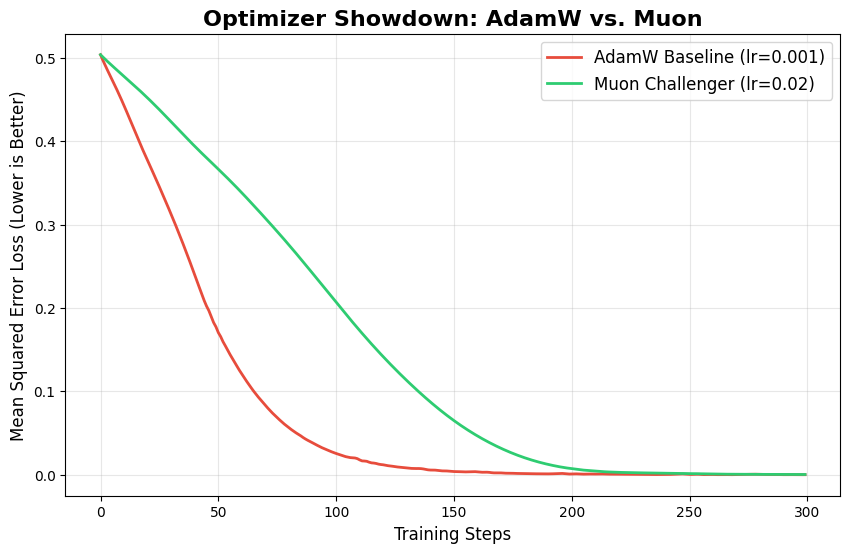

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time

# --- 1. THE HARDWARE & DATA ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on: {device}")

# Create a synthetic dataset (A tough, non-linear math problem)
torch.manual_seed(42)
B, D_in, D_out = 1024, 256, 128
X = torch.randn(B, D_in, device=device)
# The target is a complex projection of the input
Y = torch.sin(X @ torch.randn(D_in, D_out, device=device)) 

# --- 2. THE NEURAL NETWORK ---
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 Linear layers to give the optimizers some matrices to chew on
        self.net = nn.Sequential(
            nn.Linear(D_in, 512, bias=False),
            nn.SiLU(),
            nn.Linear(512, 512, bias=False),
            nn.SiLU(),
            nn.Linear(512, D_out, bias=False)
        )
    def forward(self, x):
        return self.net(x)

# Instantiate two identical models
model_adam = SimpleMLP().to(device)
model_muon = SimpleMLP().to(device)

# Copy the exact same starting weights so it's a fair race
model_muon.load_state_dict(model_adam.state_dict())

# --- 3. THE MUON OPTIMIZER CLASS ---
class Muon(torch.optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95):
        defaults = dict(lr=lr, momentum=momentum)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            
            for p in group['params']:
                if p.grad is None: continue
                
                G = p.grad
                state = self.state[p]
                if 'momentum_buffer' not in state:
                    state['momentum_buffer'] = torch.zeros_like(G)
                
                buf = state['momentum_buffer']
                buf.mul_(momentum).add_(G, alpha=1 - momentum)
                
                # Newton-Schulz Orthogonalization
                assert len(buf.shape) == 2, "Muon requires 2D matrices!"
                m, n = buf.shape
                transposed = m > n
                X_opt = buf.T if transposed else buf
                    
                X_opt = X_opt / (torch.linalg.matrix_norm(X_opt) + 1e-8)
                for _ in range(5):
                    A = X_opt @ X_opt.T
                    X_opt = 1.5 * X_opt - 0.5 * (A @ X_opt)
                    
                if transposed: X_opt = X_opt.T
                    
                p.add_(X_opt, alpha=-lr)

# --- 4. OPTIMIZER SETUP ---
# Baseline: Pure AdamW
opt_pure_adam = torch.optim.AdamW(model_adam.parameters(), lr=1e-3)

# Challenger: Hybrid Muon (All our layers are 2D here, so Muon takes them all)
muon_params = [p for p in model_muon.parameters() if len(p.shape) == 2]
opt_hybrid_muon = Muon(muon_params, lr=0.02) # Notice the massive learning rate!

# --- 5. THE RACETRACK (TRAINING LOOP) ---
steps = 300
loss_fn = nn.MSELoss()

history_adam = []
history_muon = []

print("🏁 Racing Optimizers for 300 steps...")

for i in range(steps):
    # AdamW Turn
    out_adam = model_adam(X)
    loss_adam = loss_fn(out_adam, Y)
    opt_pure_adam.zero_grad()
    loss_adam.backward()
    opt_pure_adam.step()
    history_adam.append(loss_adam.item())

    # Muon Turn
    out_muon = model_muon(X)
    loss_muon = loss_fn(out_muon, Y)
    opt_hybrid_muon.zero_grad()
    loss_muon.backward()
    opt_hybrid_muon.step()
    history_muon.append(loss_muon.item())

print("✅ Race Complete!")

# --- 6. PLOTTING THE RESULTS ---
plt.figure(figsize=(10, 6))
plt.plot(history_adam, label='AdamW Baseline (lr=0.001)', color='#e74c3c', linewidth=2)
plt.plot(history_muon, label='Muon Challenger (lr=0.02)', color='#2ecc71', linewidth=2)

plt.title("Optimizer Showdown: AdamW vs. Muon", fontsize=16, fontweight='bold')
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Mean Squared Error Loss (Lower is Better)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()